<a href="https://colab.research.google.com/github/vanashreenarvekar-hub/Deep-Learning-using-Keras/blob/main/task6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Aim

To implement and compare Recurrent Neural Network (RNN) and Long Short-Term Memory (LSTM) models for sequential data processing and sentiment classification.

In [1]:
# Task 6: Sequence Modeling using RNN and LSTM Networks

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("Libraries imported successfully!")

TensorFlow version: 2.21.0
Libraries imported successfully!


Dataset

The IMDB Movie Reviews Dataset contains 50,000 movie reviews labeled as positive or negative. It is divided into 25,000 training reviews and 25,000 testing reviews. The reviews are represented as sequences of word indices and padded to a fixed length for model training.

Theory

A Recurrent Neural Network (RNN) is a neural network designed to process sequential data. It maintains a hidden state that carries information from earlier time steps. However, standard RNNs may struggle to learn long-term dependencies because of vanishing gradients.
Long Short-Term Memory (LSTM) is an improved recurrent architecture that uses a cell state and three main gates: input, forget, and output gates. These mechanisms help the model retain or discard information over longer sequences.
In this assignment, both models classify movie reviews as positive or negative. Their performance is evaluated using test accuracy and loss, while training curves are used to compare their learning behavior.

In [2]:
# Load the IMDB Movie Reviews dataset

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

vocab_size = 10000
max_length = 200

(x_train, y_train), (x_test, y_test) = imdb.load_data(
    num_words=vocab_size
)

print("Dataset loaded successfully!")
print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))
print("Number of classes:", len(np.unique(y_train)))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dataset loaded successfully!
Training samples: 25000
Testing samples: 25000
Number of classes: 2


In [3]:
# Pad sequences to a fixed length

x_train = pad_sequences(
    x_train,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

x_test = pad_sequences(
    x_test,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

print("Training shape:", x_train.shape)
print("Testing shape:", x_test.shape)
print("Sequence preparation completed!")

Training shape: (25000, 200)
Testing shape: (25000, 200)
Sequence preparation completed!


In [4]:
# Build a Simple RNN model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

rnn_model = Sequential([
    Embedding(vocab_size, 32, input_length=max_length),
    SimpleRNN(32),
    Dense(1, activation="sigmoid")
])

rnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

rnn_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Train the RNN model

rnn_history = rnn_model.fit(
    x_train,
    y_train,
    epochs=3,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.5041 - loss: 0.6938 - val_accuracy: 0.4966 - val_loss: 0.6932
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.5951 - loss: 0.6636 - val_accuracy: 0.5016 - val_loss: 0.7085
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - accuracy: 0.6911 - loss: 0.5292 - val_accuracy: 0.5008 - val_loss: 0.8103


In [6]:
# Build an LSTM model

from tensorflow.keras.layers import LSTM

lstm_model = Sequential([
    Embedding(vocab_size, 32, input_length=max_length),
    LSTM(32),
    Dense(1, activation="sigmoid")
])

lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Train the LSTM model

lstm_history = lstm_model.fit(
    x_train,
    y_train,
    epochs=3,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 75ms/step - accuracy: 0.5198 - loss: 0.6905 - val_accuracy: 0.6726 - val_loss: 0.6204
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - accuracy: 0.6001 - loss: 0.6611 - val_accuracy: 0.5186 - val_loss: 0.6891
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 22s 84ms/step - accuracy: 0.5325 - loss: 0.6825 - val_accuracy: 0.5880 - val_loss: 0.6830


In [8]:
# Evaluate RNN and LSTM on the test dataset

rnn_loss, rnn_accuracy = rnn_model.evaluate(
    x_test, y_test, verbose=0
)

lstm_loss, lstm_accuracy = lstm_model.evaluate(
    x_test, y_test, verbose=0
)

print("Simple RNN Test Accuracy:", round(rnn_accuracy * 100, 2), "%")
print("LSTM Test Accuracy:", round(lstm_accuracy * 100, 2), "%")

Simple RNN Test Accuracy: 50.45 %
LSTM Test Accuracy: 58.02 %


In [9]:
# Create a performance comparison table

comparison = pd.DataFrame([
    {
        "Model": "Simple RNN",
        "Test Loss": rnn_loss,
        "Test Accuracy (%)": rnn_accuracy * 100
    },
    {
        "Model": "LSTM",
        "Test Loss": lstm_loss,
        "Test Accuracy (%)": lstm_accuracy * 100
    }
])

comparison["Test Loss"] = comparison["Test Loss"].round(4)
comparison["Test Accuracy (%)"] = comparison["Test Accuracy (%)"].round(2)

display(comparison)

,Model,Test Loss,Test Accuracy (%)
0,Simple RNN,0.8005,50.45
1,LSTM,0.6840,58.02


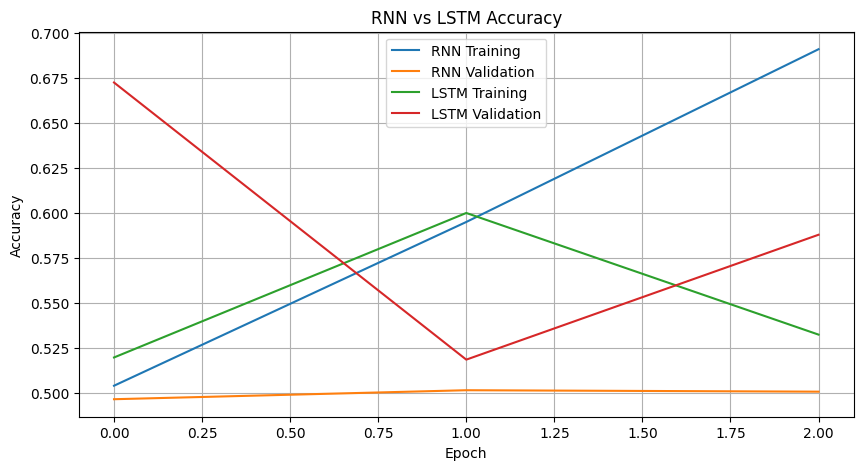

In [10]:
# Compare training and validation accuracy

plt.figure(figsize=(10, 5))

plt.plot(rnn_history.history["accuracy"], label="RNN Training")
plt.plot(rnn_history.history["val_accuracy"], label="RNN Validation")
plt.plot(lstm_history.history["accuracy"], label="LSTM Training")
plt.plot(lstm_history.history["val_accuracy"], label="LSTM Validation")

plt.title("RNN vs LSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [11]:
# Predict sentiment for a sample review

word_index = imdb.get_word_index()

def encode_review(text):
    words = text.lower().split()
    sequence = [
        word_index.get(word, 2) + 3
        for word in words
    ]
    return pad_sequences(
        [sequence],
        maxlen=max_length,
        padding="post",
        truncating="post"
    )

sample_review = "This movie was amazing and the acting was excellent"

encoded_review = encode_review(sample_review)

rnn_prediction = rnn_model.predict(encoded_review, verbose=0)[0][0]
lstm_prediction = lstm_model.predict(encoded_review, verbose=0)[0][0]

print("Sample review:", sample_review)
print("RNN sentiment:", "Positive" if rnn_prediction >= 0.5 else "Negative")
print("LSTM sentiment:", "Positive" if lstm_prediction >= 0.5 else "Negative")

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Sample review: This movie was amazing and the acting was excellent
RNN sentiment: Positive
LSTM sentiment: Positive


Algorithm
1. Import the required libraries.
2. Load the IMDB dataset.
3. Pad and truncate review sequences.
4. Build and compile the Simple RNN model.
5. Train the RNN and record its history.
6. Build and train the LSTM model.
7. Evaluate both models on the test dataset.
8. Compare their accuracy and loss.
9. Plot training and validation accuracy.
10. Predict the sentiment of a sample review.

Result

The Simple RNN and LSTM models were implemented for movie-review sentiment classification. Their test accuracy and loss were measured, and their training and validation accuracy were visualized. The resulting comparison helps demonstrate the differences between basic recurrent networks and LSTM networks.

Conclusion

This assignment demonstrated sequence classification using Simple RNN and LSTM architectures. The Simple RNN processes sequential information through its hidden state, while LSTM uses gates and a cell state to preserve information over longer sequences. Comparing both models using test metrics and training curves provides insight into their learning performance and ability to model sequential dependencies.